In [1]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 7.0 MB/s eta 0:00:15
   - -------------------------------------- 2.6/101.7 MB 9.1 MB/s eta 0:00:11
   - -------------------------------------- 4.7/101.7 MB 9.6 MB/s eta 0:00:11
   -- ------------------------------------- 5.5/101.7 MB 7.7 MB/s eta 0:00:13
   -- ------------------------------------- 7.3/101.7 MB 7.9 MB/s eta 0:00:12
   --- ------------------------------------ 9.4/101.7 MB 8.4 MB/s eta 0:00:11
   ---- ----------------------------------- 11.8/101.7 MB 8.7 MB/s eta 0:00:11
   ----- ---------------------------------- 13.6/101.7 MB 8.8 MB/s eta 0:00:11
   ------ --------------------------------- 15.5/101.7 MB 8.7 MB/s eta 0:00:10
   ------ --------------------------------- 17.6/101.7 MB 8.8 MB/s eta 0:00:10
   ------- -------------------------------- 19.4/101.7 MB 8.8 MB/s eta 0:00:10
   -------- ------------------------------- 21.8/101.7 MB 9.0 MB/s

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import joblib

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="pastel")

BASE_DIR = 'C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer'
PROCESSED_DIR = f'{BASE_DIR}/processed/'
MODELS_DIR = f'{BASE_DIR}/models/'

print("--- Starting Model Training Pipeline ---")

--- Starting Model Training Pipeline ---


In [3]:
# 1. Load the Processed Data
print("Loading Parquet files...")
X_train = pd.read_parquet(f'{PROCESSED_DIR}X_train.parquet')
X_test = pd.read_parquet(f'{PROCESSED_DIR}X_test.parquet')

y_train = pd.read_parquet(f'{PROCESSED_DIR}y_train.parquet').squeeze()
y_test = pd.read_parquet(f'{PROCESSED_DIR}y_test.parquet').squeeze()

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading Parquet files...
Training data shape: (180568, 52)
Testing data shape: (45143, 52)


In [4]:
# 2. Train Random Forest (Baseline)
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")


Training Random Forest Classifier...

--- Random Forest Performance ---
Accuracy: 0.9999


In [5]:
# 3. Train XGBoost (Advanced)
print("\nTraining XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print("\n--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")


Training XGBoost Classifier...

--- XGBoost Performance ---
Accuracy: 0.9999



Detailed Classification Report (XGBoost):
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



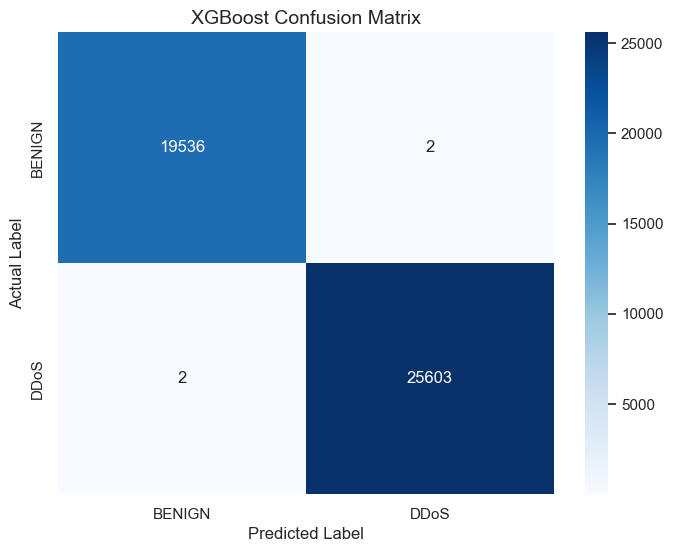

In [6]:
# 4. Detailed Evaluation (Winner: XGBoost)
print("\nDetailed Classification Report (XGBoost):")
# Target 0 is BENIGN, Target 1 is DDoS
print(classification_report(y_test, xgb_preds, target_names=['BENIGN', 'DDoS']))
# Plot Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['BENIGN', 'DDoS'], yticklabels=['BENIGN', 'DDoS'])
plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

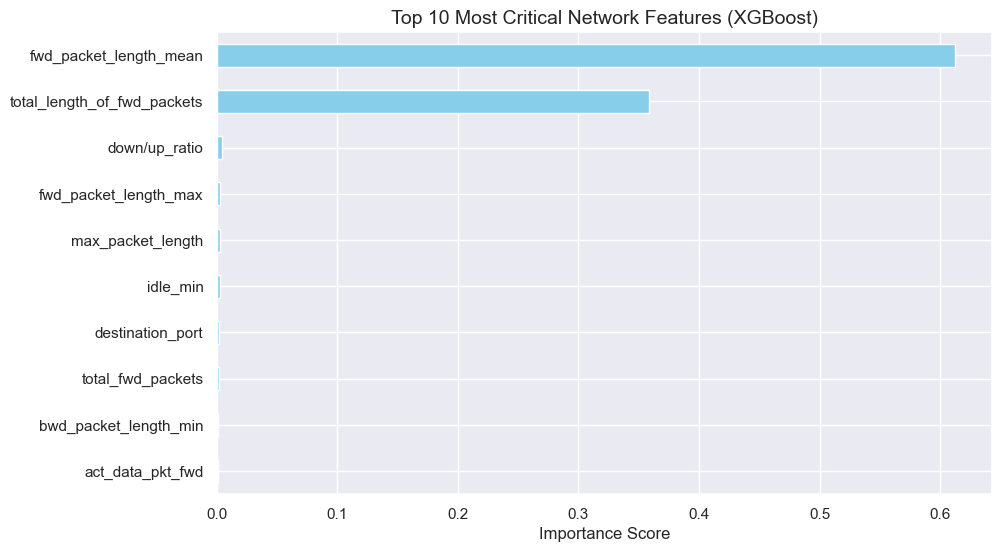

In [7]:
# 5. Feature Importance
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Critical Network Features (XGBoost)', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

In [8]:
# 6. Save the Final Model
model_path = f'{MODELS_DIR}xgb_ddos_detector.pkl'
joblib.dump(xgb_model, model_path)
print(f"\nPipeline Complete! Model successfully saved to: {model_path}")


Pipeline Complete! Model successfully saved to: C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer/models/xgb_ddos_detector.pkl
